# 0. Configuración de entorno

In [1]:
import os
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import fisher_exact, spearmanr, mannwhitneyu
from statsmodels.stats.multitest import multipletests
import warnings
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.feature_selection import VarianceThreshold
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.metrics import concordance_index_censored
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from lifelines.plotting import add_at_risk_counts

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Cargar Base de Datos Clínica
Se carga la base de datos clínica y se filtra para obtener solo los pacietnes con AVCI.

Dentro de estos pacientes se definen como "trombosis" aquellos con trombosis y como "notrombosis" los pacientes que no han padecido trombosis

In [2]:
df_clinica = pd.read_csv("../../clinica/BDD_Clinica.csv")
df_clinica['DNA_numeric'] = df_clinica['DNA_numeric'].astype(str).str.replace(r'\.0$', '', regex=True).str.strip()

df_clinica_agenesia = df_clinica[df_clinica['AGENESIA_CONFIRMADA (No=N, Sí=Sí)'] == 'SÍ']

trombosis = df_clinica_agenesia[df_clinica_agenesia['TROMBOSIS'] == 'SÍ']['DNA_numeric'].tolist()
notrombosis = df_clinica_agenesia[df_clinica_agenesia['TROMBOSIS'] == 'NO']['DNA_numeric'].tolist()
pacientes_validos = trombosis + notrombosis

print(f"Pacientes en Excel clínico con AVCI: {len(trombosis)} pacientes con trombosis + {len(notrombosis)} pacientes sin trombosis.")

Pacientes en Excel clínico con AVCI: 70 pacientes con trombosis + 30 pacientes sin trombosis.


# Cargar y cruzar las matrices genómicas
Se importan las matrices de anotaciones funcionales (df_anno) y de genotipos (df_geno).

Se normalizan los identificadores para que coincidan con los de la base de datos clínica y se realiza el merge entre las dos matrices, solo con los pacientes que se encuentren en la BDD.

In [3]:
df_anno = pd.read_csv("../resultados/matriz_anotaciones.tsv", sep='\t')
df_geno = pd.read_csv("../resultados/matriz_genotipos.tsv", sep='\t')

def normalizar_id(id_sucio):
    # Limpieza
    id_str = str(id_sucio).upper().strip()
    
    # Separar por marcas de secuenciación
    id_str = re.split(r'_S|_E|_Z|__', id_str)[0]
    
    # Encontrar todos los números y pegarlos (para casos como 21-045 -> 21045)
    nums = "".join(re.findall(r'\d+', id_str))
    
    # Si el número es largo y está duplicado (ej. 241055241055)
    # Si tiene 10 o 12 cifras y la primera mitad es igual a la segunda, se corta
    if len(nums) in [10, 12]:
        mitad = len(nums) // 2
        if nums[:mitad] == nums[mitad:]:
            nums = nums[:mitad]
    
    # Prefijo 21 para los de 3 cifras
    if len(nums) == 3:
        return "21" + nums
    
    return nums

columnas_fijas = ['CHROM', 'POS', 'REF', 'ALT']
df_geno = df_geno.rename(columns={col: normalizar_id(col) for col in df_geno.columns if col not in columnas_fijas})

# Confirmar que pacientes están secuenciados
pacientes_en_matriz = [p for p in pacientes_validos if p in df_geno.columns]
trombosis_finales = [p for p in trombosis if p in df_geno.columns]
notrombosis_finales = [p for p in notrombosis if p in df_geno.columns]

# Cruzar las matrices quitando a los pacientes que no sirven
df_geno_limpio = df_geno[columnas_fijas + pacientes_en_matriz].copy()
df = pd.merge(df_anno, df_geno_limpio, on=['CHROM', 'POS', 'REF', 'ALT'])
print(f"Trabajando con {len(trombosis_finales)} pacientes con trombosis y {len(notrombosis_finales)} sin trombosis.")

Trabajando con 69 pacientes con trombosis y 30 sin trombosis.


Media global de la cohorte: 40769 variantes por paciente.
Rango: de 202 a 94741 variantes.

10 Pacientes con más variantes


,Paciente,Total_Variantes,Grupo
0,24850,94741,Trombosis
1,23503,92143,No Trombosis
2,24571,88879,Trombosis
3,22151,53476,No Trombosis
4,22147,48265,No Trombosis
5,25174,45405,No Trombosis
6,241133,45394,Trombosis
7,25173,44860,Trombosis
8,23053,44640,Trombosis
9,20403,44440,Trombosis



10 Pacientes con menos variantes


,Paciente,Total_Variantes,Grupo
89,21166,37547,Trombosis
90,23165,37499,Trombosis
91,21225,37418,Trombosis
92,21235,36901,Trombosis
93,21204,34898,Trombosis
94,21221,1457,Trombosis
95,21206,1310,Trombosis
96,21230,1268,No Trombosis
97,21156,1223,No Trombosis
98,21237,202,No Trombosis


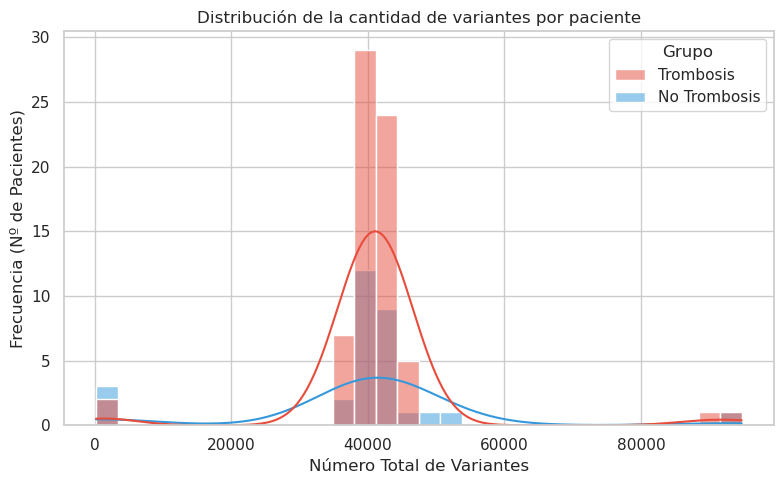

In [4]:
# Mapeo de genotipos 
# Si es 0/1 o 1/1, lo contamos como 1 (tiene la variante). Si es 0/0 o ./. es 0.
mapa_genotipos = {'0/0': 0, '0/1': 1, '1/0': 1, '1/1': 1, '0|0': 0, '0|1': 1, '1|0': 1, '1|1': 1}

# Extraer solo las columnas de los pacientes, rellenar vacíos y convertir a números
df_genotipos = (
    df[pacientes_en_matriz]
    .replace(['./.', '.'], '0/0')  # Asumir que la falta de lectura es ausencia de mutación
    .replace(mapa_genotipos)
    .apply(pd.to_numeric, errors='coerce')
    .fillna(0)
    .astype(int)
)

# Sumar cuántas variantes tiene cada paciente (sumar la columna)
conteo_variantes = df_genotipos.sum(axis=0).sort_values(ascending=False)

# Crear un DataFrame limpio para visualizarlo
df_conteo = conteo_variantes.reset_index()
df_conteo.columns = ['Paciente', 'Total_Variantes']

# Añadir a qué grupo pertenece para tener más contexto
df_conteo['Grupo'] = df_conteo['Paciente'].apply(lambda x: 'Trombosis' if x in trombosis_finales else 'No Trombosis')


print(f"Media global de la cohorte: {df_conteo['Total_Variantes'].mean():.0f} variantes por paciente.")
print(f"Rango: de {df_conteo['Total_Variantes'].min()} a {df_conteo['Total_Variantes'].max()} variantes.\n")

print("10 Pacientes con más variantes")
display(df_conteo.head(10))

print("\n10 Pacientes con menos variantes")
display(df_conteo.tail(10))

plt.figure(figsize=(8, 5))
sns.histplot(data=df_conteo, x='Total_Variantes', hue='Grupo', bins=30, kde=True, palette={'Trombosis': '#e74c3c', 'No Trombosis': '#3498db'})
plt.title("Distribución de la cantidad de variantes por paciente")
plt.xlabel("Número Total de Variantes")
plt.ylabel("Frecuencia (Nº de Pacientes)")
plt.tight_layout()
plt.show()

# PCA

In [5]:
def pca_poblacional(df_completo, casos, controles, excluir_pacientes=None, titulo='PCA de Variantes Comunes', ruta_guardar='None'):
    
    if excluir_pacientes is None:
        excluir_pacientes = []
        
    # Asegurar que la columna de frecuencia alélica poblacional de gnomAD es numérica
    df_work = df_completo.copy()
    df_work['dbNSFP_gnomAD4.1_joint_NFE_AF'] = pd.to_numeric(df_work['dbNSFP_gnomAD4.1_joint_NFE_AF'], errors='coerce')
    
    # Filtrar variantes comunes (MAF > 0.05) excluyendo NaNs
    df_comunes = df_work[df_work['dbNSFP_gnomAD4.1_joint_NFE_AF'] > 0.05].copy()
    
    # Reducir el número de variantes aleatorias si supera las 20,000
    if len(df_comunes) > 20000:
        df_comunes = df_comunes.sample(n=20000, random_state=42)
    print(f"Variantes comunes (MAF > 0.05) seleccionadas para el PCA: {len(df_comunes)}")
    
    # Concatenar listas y filtrar pacientes reales en el df
    pacientes_objetivo = [p for p in (casos + controles) if p not in excluir_pacientes]
    pacientes_presentes = [p for p in pacientes_objetivo if p in df_comunes.columns]
    
    # Conversión a matriz numérica aditiva (0=Ref/Ref, 1=Heterocigoto, 2=Alt/Alt)
    mapa_genotipos_pca = {'0/0': 0, '0/1': 1, '1/0': 1, '1/1': 2, '0|0': 0, '0|1': 1, '1|0': 1, '1|1': 2}
    
    df_geno_comunes = (
        df_comunes[pacientes_presentes]
        .replace(['./.', '.'], '0/0')
        .replace(mapa_genotipos_pca)
        .apply(pd.to_numeric, errors='coerce')
        .fillna(0)  # Ausencia de lectura se imputa como referencia
        .astype(int)
    )
    
    # Transponer la matriz para que las filas representen a los pacientes antes del escalado
    df_pca_input = df_geno_comunes.T
    
    # Estandarización de los datos
    scaler = StandardScaler()
    datos_escalados = scaler.fit_transform(df_pca_input)
    
    # Cálculo del PCA
    pca = PCA(n_components=2)
    componentes = pca.fit_transform(datos_escalados)
    
    
    df_pca = pd.DataFrame(data=componentes, columns=['PC1', 'PC2'])
    df_pca['Paciente'] = df_pca_input.index
    df_pca['Grupo'] = df_pca['Paciente'].apply(lambda x: 'Trombosis' if x in casos else 'No Trombosis')
    
    # Extraer ratio de varianza explicada
    var_explicada = pca.explained_variance_ratio_
    
    
    sns.set_context("talk")
    
    plt.figure(figsize=(9, 7))
    sns.scatterplot(
        data=df_pca, 
        x='PC1', 
        y='PC2', 
        hue='Grupo', 
        palette={'Trombosis': '#e74c3c', 'No Trombosis': '#3498db'}, 
        s=100,
        alpha=0.8,
        edgecolor='w'
    )
    plt.title(f'{titulo}\n(N = {len(pacientes_presentes)} pacientes)', fontsize=28)
    plt.xlabel(f'PC1 ({var_explicada[0]*100:.1f}% varianza)', fontsize=24)
    plt.ylabel(f'PC2 ({var_explicada[1]*100:.1f}% varianza)', fontsize=24)
    
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    
    plt.legend(title='Grupo', fontsize=14, title_fontsize=24)
    
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(ruta_guardar, format='pdf', bbox_inches='tight', dpi=300)
    plt.show()
    
    
    return df_pca

Variantes comunes (MAF > 0.05) seleccionadas para el PCA: 17531


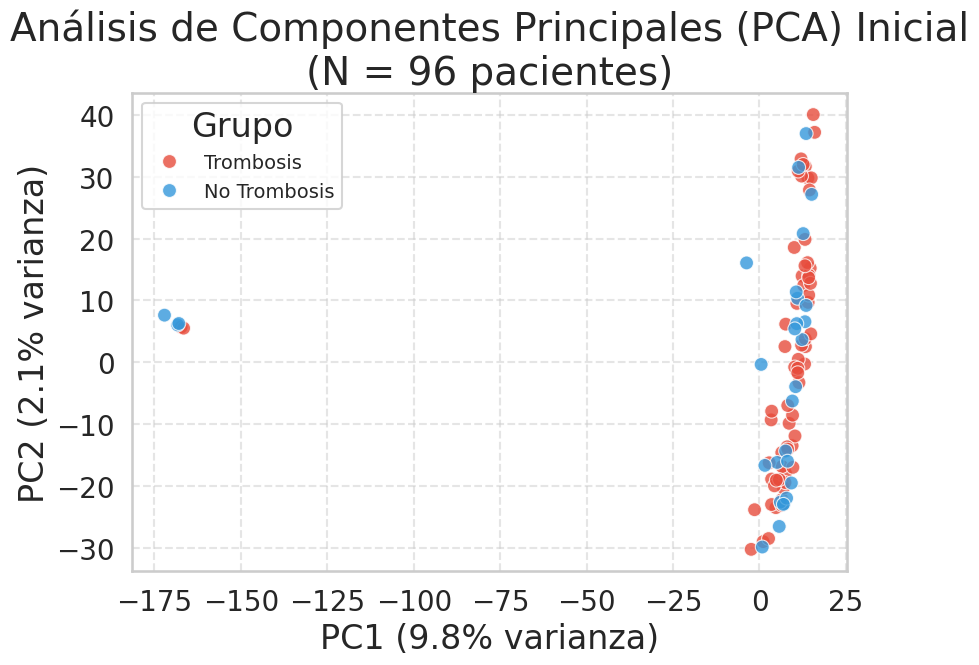

 Pacientes outliers (>3 SD): ['21206', '21221', '21230', '21237', '21156']


In [6]:
# Definición de la exclusión fija de muestras provenientes de FASTQ
pacientes_fastq = ['24850', '23503', '24571']

df_pca_1 = pca_poblacional(
    df_completo=df, 
    casos=trombosis_finales, 
    controles=notrombosis_finales, 
    excluir_pacientes=pacientes_fastq,
    titulo='Análisis de Componentes Principales (PCA) Inicial',
    ruta_guardar='resultados/pca_inicial.pdf'
)


# Calcular la media y desviación estándar de PC1 y PC2
mean_pc1, std_pc1 = df_pca_1['PC1'].mean(), df_pca_1['PC1'].std()
mean_pc2, std_pc2 = df_pca_1['PC2'].mean(), df_pca_1['PC2'].std()

# Identificar pacientes fuera del rango de +- 3 SD
outliers_pc1 = df_pca_1[np.abs(df_pca_1['PC1'] - mean_pc1) > 3 * std_pc1]['Paciente'].tolist()
outliers_pc2 = df_pca_1[np.abs(df_pca_1['PC2'] - mean_pc2) > 3 * std_pc2]['Paciente'].tolist()


ids_outliers_1 = list(set(outliers_pc1 + outliers_pc2))

print(f" Pacientes outliers (>3 SD): {ids_outliers_1}")

trombosis_saneados = [p for p in trombosis_finales if p not in ids_outliers_1 and p not in pacientes_fastq]
notrombosis_saneados = [p for p in notrombosis_finales if p not in ids_outliers_1 and p not in pacientes_fastq]

Variantes comunes (MAF > 0.05) seleccionadas para el PCA: 17531


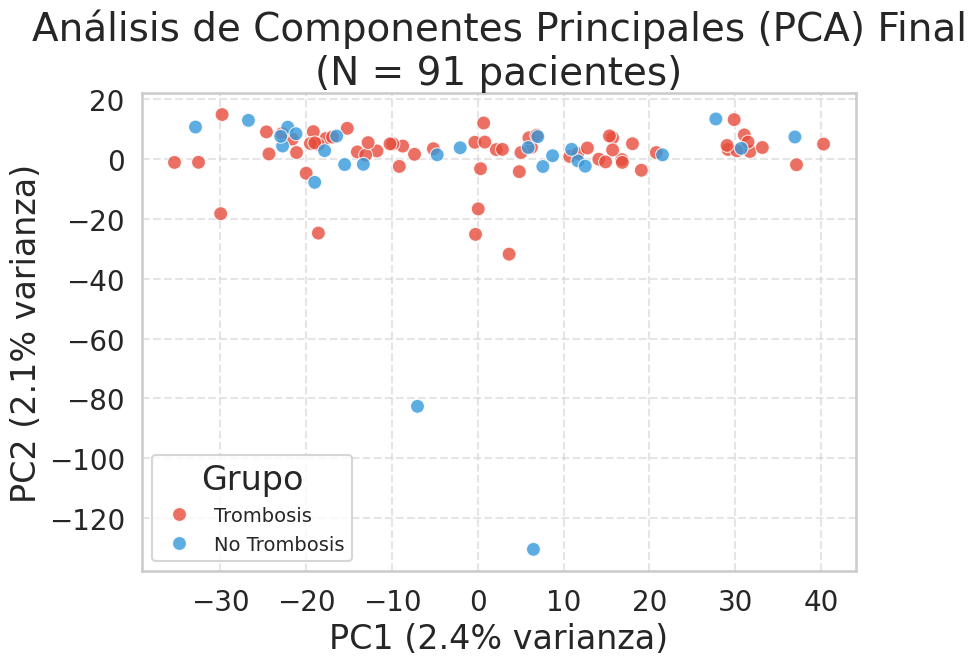

In [7]:
df_pca_2 = pca_poblacional(
    df_completo=df, 
    casos=trombosis_saneados, 
    controles=notrombosis_saneados,
    excluir_pacientes=[],
    titulo='Análisis de Componentes Principales (PCA) Final',
    ruta_guardar='resultados/pca_final.pdf'
)

In [8]:
ids_clinica = set(df_clinica['DNA_numeric'].tolist())
ids_vcf = set([col for col in df_geno.columns if col not in columnas_fijas])
outliers_pca = set(ids_outliers_1)

# Construir listas finales (limpios + nuevos FASTQ)
trombosis_finales = sorted(list(set(trombosis_saneados + [p for p in pacientes_fastq if p in trombosis])))
notrombosis_finales = sorted(list(set(notrombosis_saneados + [p for p in pacientes_fastq if p in notrombosis])))
pacientes_finales = sorted(trombosis_finales + notrombosis_finales)

print("COHORTE FINAL:")
print(f"  - TOTAL PACIENTES (N):  {len(pacientes_finales)}")
print(f"  - Casos (Trombosis):    {len(trombosis_finales)}")
print(f"  - Controles (Sanos):    {len(notrombosis_finales)}")

COHORTE FINAL:
  - TOTAL PACIENTES (N):  94
  - Casos (Trombosis):    67
  - Controles (Sanos):    27


# Descripción de la cohorte

In [9]:
df_clinica_final = df_clinica.set_index('DNA_numeric').loc[pacientes_finales].copy()

df_clinica_final['TROMBOSIS'] = df_clinica_final['TROMBOSIS'].astype(str).str.strip().str.lower().isin(['si', 'sí'])

# Tamaño de la cohorte
N_total = len(df_clinica_final)
print(f"Total de pacientes incluidos tras control de calidad: {N_total}")

# Edad Media y Rango Intercuartílico (IQR)
df_clinica_final['EDAD'] = pd.to_numeric(df_clinica_final['EDAD'], errors='coerce')
edad_mediana = df_clinica_final['EDAD'].median()
edad_q1 = df_clinica_final['EDAD'].quantile(0.25)
edad_q3 = df_clinica_final['EDAD'].quantile(0.75)
print(f"Edad al diagnóstico/seguimiento (Mediana [IQR]): {edad_mediana:.1f} años [{edad_q1:.1f} - {edad_q3:.1f}]")

# Distribución por Sexo
col_sexo = 'SEXO' 
mujeres = (df_clinica_final[col_sexo].astype(str).str.strip().str.upper() == 'MUJER').sum()
hombres = (df_clinica_final[col_sexo].astype(str).str.strip().str.upper() == 'HOMBRE').sum()

porcentaje_mujeres = (mujeres / N_total) * 100
porcentaje_hombres = (hombres / N_total) * 100

print(f"Mujeres: {mujeres} ({porcentaje_mujeres:.1f}%)")
print(f"Hombres: {hombres} ({porcentaje_hombres:.1f}%)")

# Tipos de Agenesia
col_agenesia = 'TIPO AGENESIA 3 CATEGORIAS' 
if col_agenesia in df_clinica_final.columns:
    tipos_agenesia = df_clinica_final[col_agenesia].value_counts()
    print("\nDistribución por tipo de Agenesia:")
    for tipo, cuenta in tipos_agenesia.items():
        print(f" - {tipo}: {cuenta} ({(cuenta/N_total)*100:.1f}%)")

# Trombosis Postnatal
eventos = df_clinica_final['TROMBOSIS'].sum() 
porcentaje_eventos = (eventos / N_total) * 100
print(f"\nPacientes con evento trombótico postnatal: {eventos} ({porcentaje_eventos:.1f}%)")
print(f"Pacientes sin evento trombótico: {N_total - eventos} ({(100 - porcentaje_eventos):.1f}%)")

# Edad a la Trombosis
casos = df_clinica_final[df_clinica_final['TROMBOSIS'] == True].copy()
casos['EDADTROMBOSIS'] = pd.to_numeric(casos['EDADTROMBOSIS'], errors='coerce')

if not casos['EDADTROMBOSIS'].dropna().empty:
    edad_trombo_mediana = casos['EDADTROMBOSIS'].median()
    edad_trombo_q1 = casos['EDADTROMBOSIS'].quantile(0.25)
    edad_trombo_q3 = casos['EDADTROMBOSIS'].quantile(0.75)
    print(f"Edad a la trombosis (Mediana [IQR]): {edad_trombo_mediana:.1f} años [{edad_trombo_q1:.1f} - {edad_trombo_q3:.1f}]")
else:
    print("Edad a la trombosis: No hay datos numéricos disponibles.")

Total de pacientes incluidos tras control de calidad: 94
Edad al diagnóstico/seguimiento (Mediana [IQR]): 44.5 años [24.8 - 58.2]
Mujeres: 54 (57.4%)
Hombres: 40 (42.6%)

Distribución por tipo de Agenesia:
 - Seg. infrahepáticos: 49 (52.1%)
 - Ag. Completa: 24 (25.5%)
 - Intrahepática: 17 (18.1%)

Pacientes con evento trombótico postnatal: 67 (71.3%)
Pacientes sin evento trombótico: 27 (28.7%)
Edad a la trombosis (Mediana [IQR]): 28.0 años [19.5 - 47.0]


# Filtrado y Priorización de Variantes Candidatas


In [10]:
# Configuración de muestras y mapeo genotípico (N=94)
pacientes_finales = trombosis_finales + notrombosis_finales
mapa_genotipos = {'0/0': 0, '0/1': 1, '1/0': 1, '1/1': 2, '0|0': 0, '0|1': 1, '1|0': 1, '1|1': 2}

df_num_final = (
    df[pacientes_finales]
    .replace(['./.', '.'], '0/0')
    .replace(mapa_genotipos)
    .apply(pd.to_numeric, errors='coerce')
    .fillna(0)
    .astype(int)
)

# Actualizar frecuencia alélica
df['AF_Interna'] = df_num_final.sum(axis=1) / (len(pacientes_validos) * 2)


try:
    with open("../../panel_genes/panel_genes.txt", "r") as f:
        genes_panel = set([line.strip().upper() for line in f if line.strip()])
except FileNotFoundError:
    genes_panel = set(df['ANN[*].GENE'].unique())

# Limpieza de identificadores de genes y extracción de scores funcionales
df['Gen_Clean'] = df['ANN[*].GENE'].astype(str).apply(lambda x: x.split(',')[0].strip().upper())
df_panel = df[df['Gen_Clean'].isin(genes_panel)].copy()

def clean_score(valor):
    if pd.isna(valor) or str(valor).strip() in ['', '.', '. , .']: return np.nan
    numeros = re.findall(r"[-+]?\d*\.\d+|\d+", str(valor))
    return max([float(n) for n in numeros]) if numeros else np.nan

df_panel['CADD_clean'] = df_panel['dbNSFP_CADD_phred'].apply(clean_score)
df_panel['REVEL_clean'] = df_panel['dbNSFP_REVEL_score'].apply(clean_score)
df_panel['gnomAD_AF'] = pd.to_numeric(df_panel['dbNSFP_gnomAD4.1_joint_NFE_AF'], errors='coerce')

# Aplicación de filtros de rareza y patogenicidad
df_priorizado = df_panel[
    ((df_panel['gnomAD_AF'] < 0.005) | (df_panel['gnomAD_AF'].isna())) & 
    (df_panel['AF_Interna'] <= 0.10) & 
    (~df_panel['CLINVAR_CLNSIG'].str.contains('enign', na=False, case=False))
].copy()

cond_high = df_priorizado['ANN[*].IMPACT'].str.contains('HIGH', na=False)
cond_sev_missense = (df_priorizado['CADD_clean'] >= 20) | (df_priorizado['REVEL_clean'] >= 0.5)
df_final = df_priorizado[cond_high | cond_sev_missense].copy()

# Recuento de alelos segregados por fenotipo
df_final['AC_Casos'] = df_num_final.loc[df_final.index, trombosis_finales].sum(axis=1)
df_final['AC_Controles'] = df_num_final.loc[df_final.index, notrombosis_finales].sum(axis=1)


print(f"Muestras analizadas: {len(pacientes_finales)} (Casos: {len(trombosis_finales)}, Controles: {len(notrombosis_finales)})")
print(f"Variantes priorizadas: {len(df_final)}")
print(f"Genes afectados: {df_final['Gen_Clean'].nunique()}")

Muestras analizadas: 94 (Casos: 67, Controles: 27)
Variantes priorizadas: 188
Genes afectados: 87


# Limpiar MNV

In [11]:
df_final['POS'] = pd.to_numeric(df_final['POS'], errors='coerce')
df_final_pos = df_final.sort_values(by=['Gen_Clean', 'POS'])
df_final_pos['Distancia_Prev'] = df_final_pos.groupby('Gen_Clean')['POS'].diff().abs()

mask_mnv_redundante = df_final_pos['Distancia_Prev'] <= 5
variantes_borradas = df_final_pos[mask_mnv_redundante]
print(f"Se han detectado y colapsado {len(variantes_borradas)} variantes redundantes (Artefactos MNV < 5 pb).")

df_final = df_final_pos[~mask_mnv_redundante].drop(columns=['Distancia_Prev']).copy()

df_final['AC_Casos'] = df_num_final.loc[df_final.index, trombosis_finales].sum(axis=1)
df_final['AC_Controles'] = df_num_final.loc[df_final.index, notrombosis_finales].sum(axis=1)

print(f"Matriz final consolidada: {len(df_final)} variantes únicas reales.")


Se han detectado y colapsado 5 variantes redundantes (Artefactos MNV < 5 pb).
Matriz final consolidada: 183 variantes únicas reales.


In [12]:
df_latex = df_final.copy().reset_index(drop=True)

diccionario_columnas = {
    'Gen Clean': 'Gen', 'Gen_Clean': 'Gen',
    'ANN[*].EFFECT': 'Efecto', 'ANN[*].HGVS_C': 'HGVS C',
    'ANN[*].HGVS_P': 'HGVS P',
    'CLINVAR_CLNSIG': 'ClinVar',
    'gnomAD_AF': 'gnomAD',
    'AC_Casos': 'Trombosis',
    'AC_Controles': 'Controles'
}

cols_existentes = [col for col in diccionario_columnas.keys() if col in df_latex.columns]
df_latex = df_latex[cols_existentes]
df_latex = df_latex.rename(columns=diccionario_columnas)
df_latex = df_latex.loc[:, ~df_latex.columns.duplicated()]

for col in ['Efecto', 'HGVS C', 'HGVS P', 'ClinVar']:
    if col in df_latex.columns:
        df_latex[col] = df_latex[col].astype(str).apply(lambda x: x.split(',')[0])

        
df_latex = df_latex.replace(['nan', 'NaN', 'None', '<NA>'], '')
df_latex = df_latex.fillna('')

def recortar_textos(texto, limite=20):
    texto_str = str(texto)
    if len(texto_str) > limite:
        return texto_str[:limite] + "..."
    return texto_str

for col in df_latex.columns:
    df_latex[col] = df_latex[col].astype(str).apply(recortar_textos)
    df_latex[col] = df_latex[col].str.replace('_', ' ')
    df_latex[col] = df_latex[col].str.replace('%', r'\%')
    df_latex[col] = df_latex[col].str.replace('&', r'\&')
    df_latex[col] = df_latex[col].str.replace('#', r'\#')
    df_latex[col] = df_latex[col].str.replace('$', r'\$')
    df_latex[col] = df_latex[col].str.replace(',', '.')
    df_latex[col] = df_latex[col].str.replace(';', '.')

df_latex.to_csv('./variantes_unicas.csv', index=False, sep=';')
print("CSV minimizado, alineado y limpio generado con éxito.")

CSV minimizado, alineado y limpio generado con éxito.


In [13]:
print(f"CARGA MUTACIONAL POR INDIVIDUO (N={len(pacientes_finales)})")
carga_por_paciente = df_num_final.loc[df_final.index].sum(axis=0)
print(f"Media global: {carga_por_paciente.mean():.2f} variantes por paciente.")
print(f"Rango: de {carga_por_paciente.min()} a {carga_por_paciente.max()} variantes.")

pacientes_cero = carga_por_paciente[carga_por_paciente == 0].index
print(f"Pacientes con 0 variantes del panel: {len(pacientes_cero)} pacientes.")

print("\nTIPO DE IMPACTO BIOLÓGICO (SnpEff)")
impacto_high = df_final['ANN[*].IMPACT'].str.contains('HIGH', na=False).sum()
impacto_moderate = len(df_final) - impacto_high
print(f"Variantes de Alto Impacto: {impacto_high} ({impacto_high/len(df_final)*100:.1f}%)")
print(f"Variantes de Impacto Moderado: {impacto_moderate} ({impacto_moderate/len(df_final)*100:.1f}%)")

print("\nFRECUENCAI POBLACIONAL (gnomAD)")
novel_vars = df_final['gnomAD_AF'].isna().sum()
print(f"Variantes ausentes en gnomAD NFE: {novel_vars} ({novel_vars/len(df_final)*100:.1f}%)")
print(f"Variantes Raras (AF < 0.5%): {len(df_final) - novel_vars}")

print("\nDISTRIBUCIÓN DE PACIENTES SIN VARIANTES")
casos_cero = [p for p in pacientes_cero if p in trombosis_finales]
controles_cero = [p for p in pacientes_cero if p in notrombosis_finales]
print(f"De los {len(pacientes_cero)} pacientes con 0 mutaciones en el panel:")
print(f"- {len(casos_cero)} son AVCI con trombosis")
print(f"- {len(controles_cero)} son AVCI sin trombosis")

CARGA MUTACIONAL POR INDIVIDUO (N=94)
Media global: 2.21 variantes por paciente.
Rango: de 0 a 11 variantes.
Pacientes con 0 variantes del panel: 9 pacientes.

TIPO DE IMPACTO BIOLÓGICO (SnpEff)
Variantes de Alto Impacto: 26 (14.2%)
Variantes de Impacto Moderado: 157 (85.8%)

FRECUENCAI POBLACIONAL (gnomAD)
Variantes ausentes en gnomAD NFE: 51 (27.9%)
Variantes Raras (AF < 0.5%): 132

DISTRIBUCIÓN DE PACIENTES SIN VARIANTES
De los 9 pacientes con 0 mutaciones en el panel:
- 6 son AVCI con trombosis
- 3 son AVCI sin trombosis


In [14]:
pacientes_cero

Index(['21084', '21090', '21163', '21223', '21226', '23219', '21214', '21218',
       '21222'],
      dtype='object')

In [15]:
print("\nGENES ESPECÍFICOS POR FENOTIPO")

# Agrupar la suma de alelos mutados por gen y ordenamos
top_casos = df_final.groupby('Gen_Clean')['AC_Casos'].sum().sort_values(ascending=False)
top_controles = df_final.groupby('Gen_Clean')['AC_Controles'].sum().sort_values(ascending=False)

print("Genes con mayor carga mutacional en AVCI + Trombosis:")
print(top_casos[top_casos > 0].head(5))

print("\nGenes con mayor carga mutacional en AVCI sin Trombosis:")
print(top_controles[top_controles > 0].head(5))


GENES ESPECÍFICOS POR FENOTIPO
Genes con mayor carga mutacional en AVCI + Trombosis:
Gen_Clean
F11         7
DGKH        7
COL5A2      6
NBEAL2      6
SERPINC1    5
Name: AC_Casos, dtype: int64

Genes con mayor carga mutacional en AVCI sin Trombosis:
Gen_Clean
COL3A1    3
LYST      3
MAST2     3
TRPM7     2
ABCG5     2
Name: AC_Controles, dtype: int64


In [16]:
print("\nRECURRENCIA ALÉLICA")

# Calcular el total de alelos mutados en toda la cohorte (Casos + Controles)
df_final['AC_Total'] = df_final['AC_Casos'] + df_final['AC_Controles']

# Agrupar por gen para ver la suma de alelos y cuántas variantes distintas hay
recurrencia = df_final.groupby('Gen_Clean').agg(
    Total_Alelos_Mutados=('AC_Total', 'sum'),
    Variantes_Distintas=('AC_Total', 'count')
)

recurrencia['Ratio_Recurrencia'] = recurrencia['Total_Alelos_Mutados'] / recurrencia['Variantes_Distintas']

recurrencia_top = recurrencia[recurrencia['Total_Alelos_Mutados'] > 1].sort_values(
    by=['Ratio_Recurrencia', 'Total_Alelos_Mutados'], ascending=[False, False]
)

print("Genes con variantes altamente recurrentes (Muchos pacientes comparten pocas variantes):")
print(recurrencia_top.head(5))


RECURRENCIA ALÉLICA
Genes con variantes altamente recurrentes (Muchos pacientes comparten pocas variantes):
           Total_Alelos_Mutados  Variantes_Distintas  Ratio_Recurrencia
Gen_Clean                                                              
KDSR                          6                    2               3.00
MYH9                          6                    2               3.00
TRPM7                         6                    2               3.00
F11                           9                    4               2.25
F8                            2                    1               2.00


# ¿Diferencia de genes según fenotipo?

In [17]:
df_temp = df_num_final.loc[df_final.index].copy()
df_temp['Gen_Clean'] = df_final['Gen_Clean']

# Agrupar por gen sumando los alelos para cada paciente
matriz_genes = df_temp.groupby('Gen_Clean').sum()

carga_genes_trombosis = matriz_genes[trombosis_finales].sum(axis=1)

top_10_genes = carga_genes_trombosis.nlargest(10).index.tolist()
print(f"Analizando los 10 genes más mutados en casos: {top_10_genes}\n")

# Burden test por gen
resultados_genes = []

for gen in top_10_genes:
    # Extraer cuántas mutaciones tiene cada paciente en este gen concreto
    mutaciones_casos = matriz_genes.loc[gen, trombosis_finales]
    mutaciones_controles = matriz_genes.loc[gen, notrombosis_finales]
    
    # Test de Mann-Whitney U 
    # alternative='greater' ¿La carga en Casos es MAYOR que en Controles?
    stat, p_val = mannwhitneyu(mutaciones_casos, mutaciones_controles, alternative='greater')
    
    resultados_genes.append({
        'Gen': gen,
        'Alelos_Mutados_Casos': mutaciones_casos.sum(),
        'Alelos_Mutados_Controles': mutaciones_controles.sum(),
        'Media_Casos': mutaciones_casos.mean(),
        'Media_Controles': mutaciones_controles.mean(),
        'P_valor': p_val
    })

df_resultados_genes = pd.DataFrame(resultados_genes)
display(df_resultados_genes)

Analizando los 10 genes más mutados en casos: ['DGKH', 'F11', 'COL5A2', 'NBEAL2', 'FLNA', 'SERPINC1', 'HPS6', 'KDSR', 'LYST', 'MYH9']



,Gen,Alelos_Mutados_Casos,Alelos_Mutados_Controles,Media_Casos,Media_Controles,P_valor
0,DGKH,7,1,0.104478,0.037037,0.147791
1,F11,7,2,0.104478,0.074074,0.401071
2,COL5A2,6,0,0.089552,0.000000,0.056069
3,NBEAL2,6,1,0.089552,0.037037,0.193888
4,FLNA,5,1,0.074627,0.037037,0.433578
5,SERPINC1,5,0,0.074627,0.000000,0.100549
6,HPS6,4,0,0.059701,0.000000,0.100509
7,KDSR,4,2,0.059701,0.074074,0.605043
8,LYST,4,3,0.059701,0.111111,0.806112
9,MYH9,4,2,0.059701,0.074074,0.605043


# ¿Pacientes con más de una mutación por gen?

In [18]:
resultados_recesivos = []

pacientes_validos = df_num_final.columns.tolist()

for paciente in pacientes_validos:
    variantes_paciente = df_num_final[df_num_final[paciente] > 0].index
    df_temp = df_final.loc[df_final.index.intersection(variantes_paciente)].copy()
    
    if df_temp.empty: 
        continue
        
    # Eventos Monogénicos (Homocigotos Reales)
    homocigotos = df_temp[df_num_final.loc[df_temp.index, paciente] == 2]
    for _, row in homocigotos.iterrows():
        resultados_recesivos.append({
            'Paciente': paciente, 
            'Grupo': 'Caso' if paciente in trombosis_finales else 'Control',
            'Gen': row['Gen_Clean'], 
            'Evento_Estructural': 'Homocigosis',
            'Variante_1': row.get('ANN[*].HGVS_C', 'n.d.'), 
            'Variante_2': 'Mismo alelo mutado',
            'Min_CADD': row['CADD_clean']
        })

    # Heterocigotos Compuestos (Variantes en trans candidatas)
    genes_multi_hit = df_temp[df_num_final.loc[df_temp.index, paciente] == 1].groupby('Gen_Clean')
    for gen, grupo in genes_multi_hit:
        if len(grupo) >= 2:
            var_list = grupo.sort_values('CADD_clean', ascending=False)
            resultados_recesivos.append({
                'Paciente': paciente, 
                'Grupo': 'Caso' if paciente in trombosis_finales else 'Control',
                'Gen': gen, 
                'Evento_Estructural': 'Candidato Het. Compuesto',
                'Variante_1': var_list.iloc[0].get('ANN[*].HGVS_C', 'n.d.'),
                'Variante_2': var_list.iloc[1].get('ANN[*].HGVS_C', 'n.d.'),
                'Min_CADD': var_list['CADD_clean'].min()
            })

df_recesivo = pd.DataFrame(resultados_recesivos)

print(f"Se han detectado {len(df_recesivo)} casos de homocigosis o heterocigosis compuesta:")
if not df_recesivo.empty:
    display(df_recesivo.sort_values(by=['Grupo', 'Min_CADD'], ascending=[True, False]))

Se han detectado 3 casos de homocigosis o heterocigosis compuesta:


,Paciente,Grupo,Gen,Evento_Estructural,Variante_1,Variante_2,Min_CADD
2,25385,Caso,SERPINC1,Homocigosis,"c.391C>T,c.247C>T",Mismo alelo mutado,28.4
1,24850,Caso,FLNA,Candidato Het. Compuesto,"c.5033C>A,c.5009C>A","c.5053A>G,c.5029A>G",22.0
0,21089,Caso,F11,Candidato Het. Compuesto,c.865+1_866-1del,c.1304+1_1304+2insGTAGAGTCACCTAAGATTTTGCGTGTCT...,NaN


In [19]:
pacientes_recesivos = ['25385', '24850', '21089']

df_clinica_idx = df_clinica.set_index('DNA_numeric')

df_fenotipos_extremos = df_clinica_idx.loc[pacientes_recesivos].iloc[:, :11]

display(df_fenotipos_extremos)

,"AGENESIA_CONFIRMADA (No=N, Sí=Sí)",SEXO,EDAD,TIPO AGENESIA 2 CATEGORIAS,TIPO AGENESIA 3 CATEGORIAS,TIPO AGENESIA 4 CATEGORIAS,TROMBOSIS,EDADTROMBOSIS,TIPODETROMBOSIS (1ª),TROMBOSISRECURRENTE,NºDEEVENTOSTROMBÓTICOS1
DNA_numeric,,,,,,,,,,,
25385,SÍ,HOMBRE,NaN,NaN,NaN,NaN,SÍ,17.0,NaN,SÍ,2.0
24850,SÍ,MUJER,36.0,Extrahepática,Seg. infrahepáticos,Renal/Infrarrenal,SÍ,23.0,DVT,SÍ,2.0
21089,SÍ,HOMBRE,86.0,Extrahepática,Seg. infrahepáticos,Renal/Infrarrenal,SÍ,72.0,DVT,SÍ,2.0


# Burden Test

In [20]:
def ejecutar_burden_test(carga_individual, casos, controles, titulo, ylabel, ruta_guardar=None):
    
    # Segmentación por grupos clínicos
    carga_casos = carga_individual[casos]
    carga_controles = carga_individual[controles]
    
    # Inferencia Estadística: Test de Mann-Whitney U (unilateral)
    # Hipótesis alternativa: El grupo de casos tiene mayor carga genética que los controles.
    stat, p_value = mannwhitneyu(carga_casos, carga_controles, alternative='greater')
    
    media_casos = carga_casos.mean()
    media_controles = carga_controles.mean()
    
    print(f"--- RESULTADOS: {titulo.upper()} ---")
    print(f"Media Casos: {media_casos:.2f} | Media Controles: {media_controles:.2f}")
    print(f"Estadístico U: {stat} | p-valor: {p_value:.4f}\n")
    
    plot_df = pd.DataFrame({
        'Carga': list(carga_casos) + list(carga_controles),
        'Grupo': ['Trombosis'] * len(carga_casos) + ['No Trombosis'] * len(carga_controles)
    })
    
    # Visualización de los resultados
    sns.set_context("notebook") 
    plt.figure(figsize=(7, 6))
    
    ax = sns.boxplot(
        data=plot_df, 
        x='Grupo', 
        y='Carga', 
        palette={'Trombosis': '#e74c3c', 'No Trombosis': '#3498db'},
        showmeans=True, 
        meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"}
    )
    
    texto_stats = (
        f"p-valor = {p_value:.4f}\n"
        f"Media Trombosis = {media_casos:.2f}\n"
        f"Media No Trombosis = {media_controles:.2f}"
    )
    
    
    y_min, y_max = ax.get_ylim()
    ax.set_ylim(y_min, y_max + (y_max - y_min) * 0.15)
    
    ax.annotate(
        texto_stats, 
        xy=(0.5, 0.96), xycoords='axes fraction', 
        ha='left', va='top', fontsize=13, color='#333333',
        bbox=dict(boxstyle="round,pad=0.5", fc="#f8f9fa", ec="#cccccc", lw=1.5)
    )
    
    
    plt.ylabel(ylabel, fontsize=20)
    plt.title(titulo, fontsize=28, pad=15)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    
    plt.grid(True, axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    
    if ruta_guardar is not None:
        os.makedirs(os.path.dirname(ruta_guardar) or '.', exist_ok=True)
        plt.savefig(ruta_guardar, format='pdf', bbox_inches='tight', dpi=300)
        print(f"Gráfico guardado en: {ruta_guardar}")
        
    plt.show()
    
    return stat, p_value


--- RESULTADOS: BURDEN TEST CONVENCIONAL ---
Media Casos: 2.36 | Media Controles: 1.81
Estadístico U: 1037.0 | p-valor: 0.1289

Gráfico guardado en: resultados/burden_test_convencional.pdf


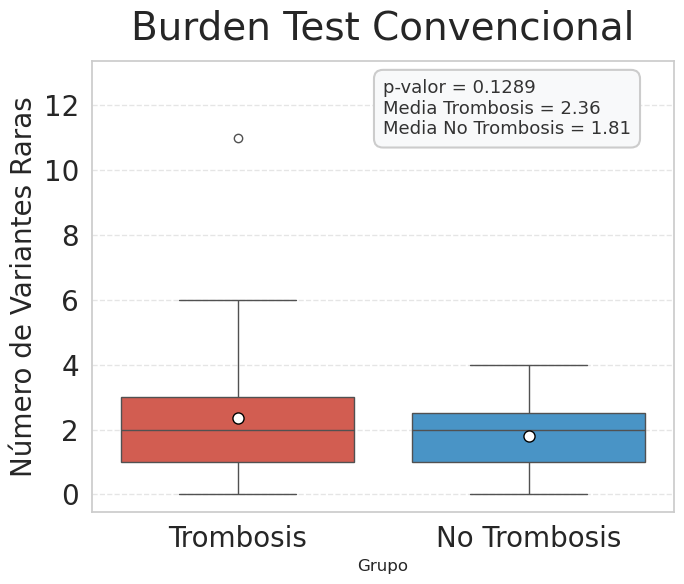

In [21]:
carga_bruta = (df_num_final.loc[df_final.index] > 0).astype(int).sum(axis=0)

stat_conv, pval_conv = ejecutar_burden_test(
    carga_individual=carga_bruta,
    casos=trombosis_finales,
    controles=notrombosis_finales,
    titulo='Burden Test Convencional',
    ylabel='Número de Variantes Raras',
    ruta_guardar='resultados/burden_test_convencional.pdf'
)

--- RESULTADOS: BURDEN TEST PONDERADO (CADD) ---
Media Casos: 59.60 | Media Controles: 44.44
Estadístico U: 1057.0 | p-valor: 0.1019

Gráfico guardado en: resultados/burden_test_ponderado.pdf


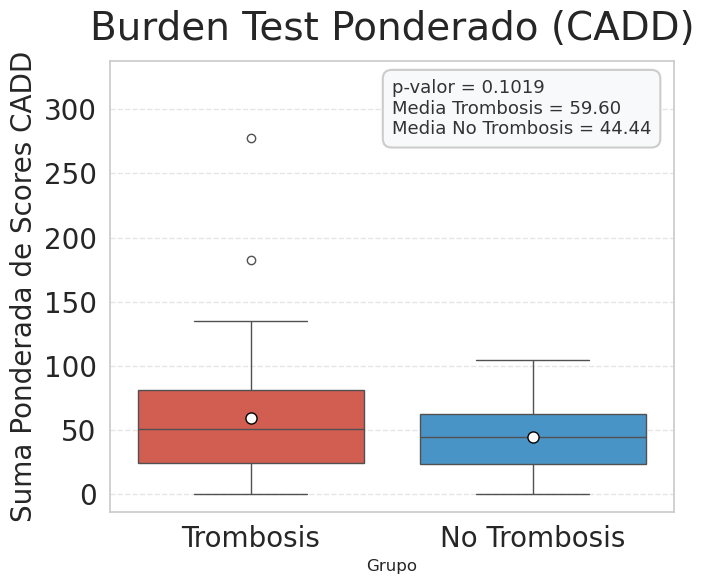

In [22]:
pesos_cadd = df_final['CADD_clean'].fillna(df_final['CADD_clean'].median()).values
carga_ponderada = df_num_final.loc[df_final.index].T.dot(pesos_cadd)

stat_pond, pval_pond = ejecutar_burden_test(
    carga_individual=carga_ponderada,
    casos=trombosis_finales,
    controles=notrombosis_finales,
    titulo='Burden Test Ponderado (CADD)',
    ylabel='Suma Ponderada de Scores CADD',
    ruta_guardar='resultados/burden_test_ponderado.pdf'
)

# Elastic-Net y Kaplan-Meier

Genes en el panel original: 87
Genes recurrentes retenidos (mutados en >= 2 pacientes): 48
 1. GENERACIÓN DEL POLYGENIC HAZARD SCORE (NESTED-CV OOF)
Iniciando 1400 combinaciones...

RESULTADO C-index Out-of-Fold: 0.5983

2. ENTRENAMIENTO DEL MODELO GLOBAL (PARA EXTRAER PARÁMETROS)
Mejor Alpha: 0.0390
Mejor L1 Ratio: 0.80

3. KAPLAN-MEIER: MEDIANAS


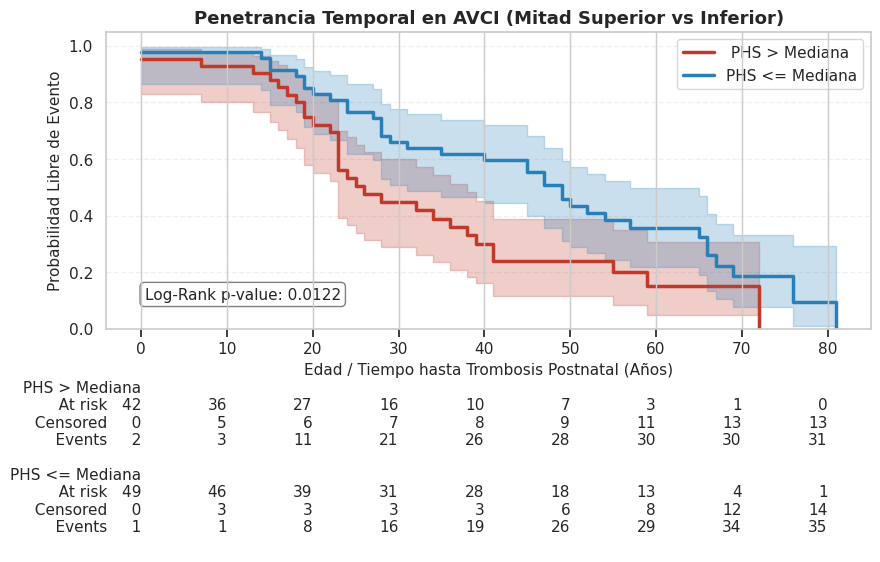


4. KAPLAN-MEIER: TERCILES


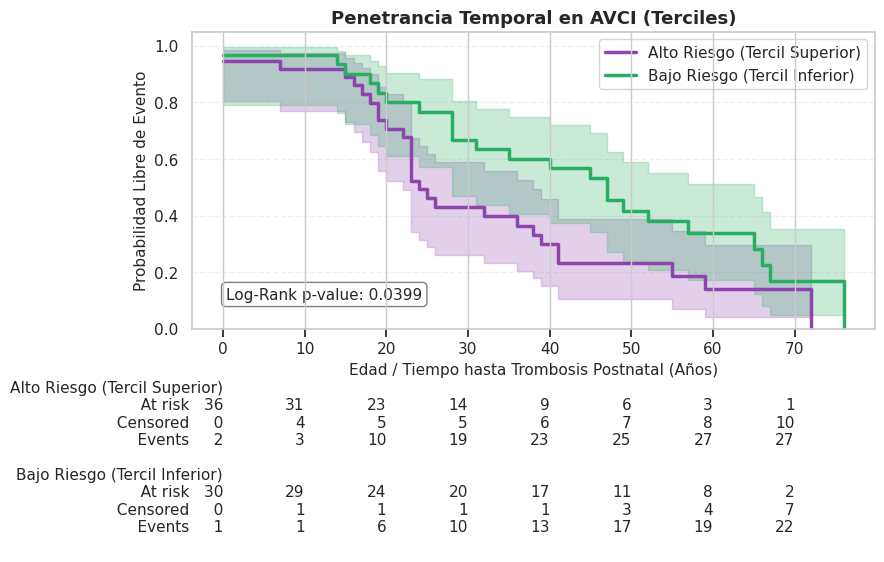


5. PERMUTATION TEST: VALIDACIÓN ESTADÍSTICA OOF EXACTA
Haciendo Validación Cruzada 1000 veces...


100%|██████████| 1000/1000 [04:36<00:00,  3.62it/s]



Se completaron 587 permutaciones válidas.


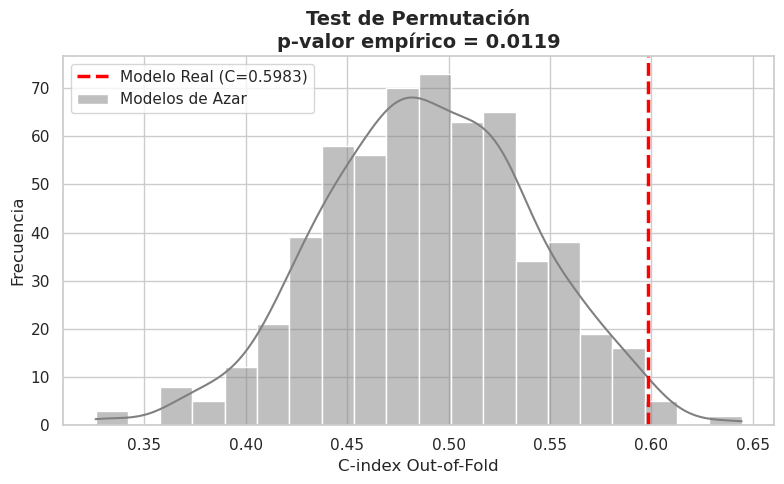


6. EXTRACCIÓN DE LA FIRMA GENÓMICA (PESOS DEL MODELO)
El modelo Elastic-Net ha seleccionado una firma de 37 genes principales:



,Gen,Coeficiente_Beta,Hazard_Ratio
3,ADGRG1,0.364582,1.439912
37,SERPINC1,0.326088,1.385538
32,NOTCH3,0.294927,1.343028
46,VPS33B,0.276930,1.319074
40,TBXAS1,0.239553,1.270682
20,HPS3,0.227734,1.255751
38,SERPIND1,0.207847,1.231025
1,ABCG5,-0.202924,0.816341
21,HPS6,0.189975,1.209220
33,PROC,0.189860,1.209081


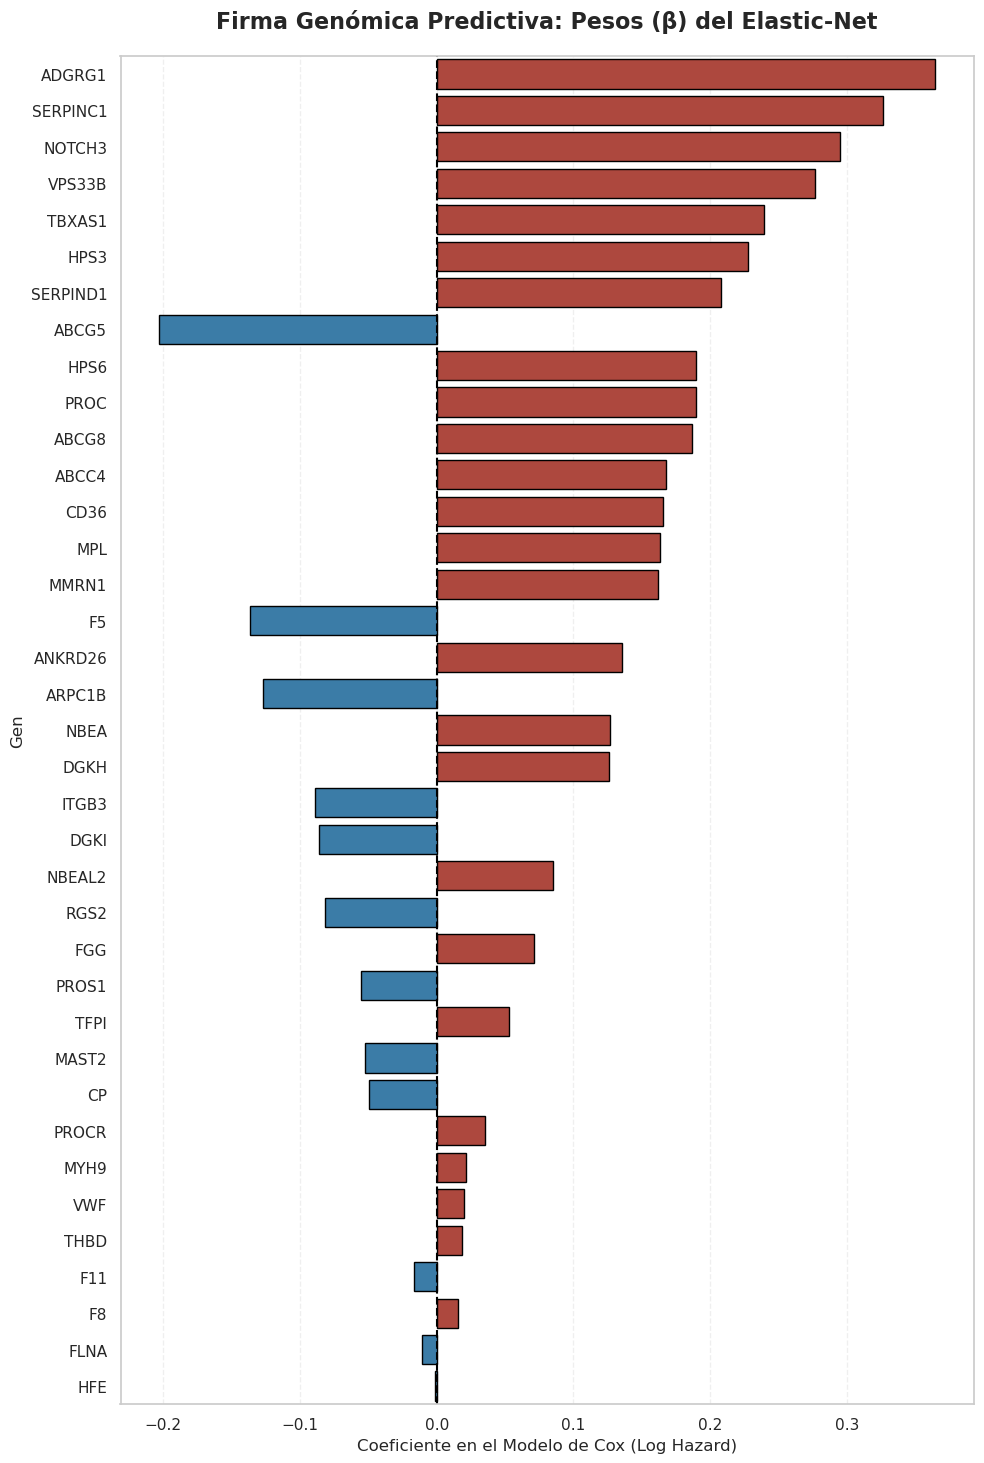

In [23]:
os.environ["PYTHONWARNINGS"] = "ignore"
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)



df_genes_temp = df_num_final.loc[df_final.index].copy()
df_genes_temp['Gen'] = df_final['Gen_Clean']

# Se suma y luego se binariza: Todo lo mayor a 0 se convierte en 1.
matriz_genes_raw = df_genes_temp.groupby('Gen').sum()
matriz_genes_raw = (matriz_genes_raw > 0).astype(int)

# Filtrar genes mutados en almenos 2 pacientes para evitar ruido
min_pacientes = 2
genes_recurrentes = matriz_genes_raw.index[matriz_genes_raw.sum(axis=1) >= min_pacientes]
matriz_genes = matriz_genes_raw.loc[genes_recurrentes]

print(f"Genes en el panel original: {len(matriz_genes_raw)}")
print(f"Genes recurrentes retenidos (mutados en >= {min_pacientes} pacientes): {len(matriz_genes)}")

# Preparación de la cohorte
df_surv = df_clinica.set_index('DNA_numeric').loc[pacientes_finales].copy()
df_surv['Evento'] = df_surv['TROMBOSIS'].apply(lambda x: True if str(x).strip().upper() == 'SÍ' else False)
df_surv['Tiempo'] = np.where(
    df_surv['Evento'] == True, 
    pd.to_numeric(df_surv['EDADTROMBOSIS'], errors='coerce'), 
    pd.to_numeric(df_surv['EDAD'], errors='coerce')
)
df_surv = df_surv.dropna(subset=['Tiempo'])

# Construir X y Y
X_genes = matriz_genes.T
y_surv = np.array(list(zip(df_surv['Evento'], df_surv['Tiempo'])), dtype=[('Evento', '?'), ('Tiempo', '<f8')])



print(" 1. GENERACIÓN DEL POLYGENIC HAZARD SCORE (NESTED-CV OOF)")
X = X_genes.copy()
oof_predictions = np.zeros(len(X))

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=123)

safe_alphas = np.logspace(-4, 0.5, 100) 

pipeline_cv = Pipeline([
    ('vt', VarianceThreshold(threshold=0.0)),
    ('scaler', StandardScaler()),
    ('coxnet', CoxnetSurvivalAnalysis(max_iter=200000, normalize=False))
])

grid_parametros = {
    "coxnet__alphas": [[a] for a in safe_alphas],
    "coxnet__l1_ratio": [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0] 
}

print(f"Iniciando {len(safe_alphas) * len(grid_parametros['coxnet__l1_ratio'])} combinaciones...")

for train_idx, test_idx in skf.split(X, df_surv['Evento']):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y_surv[train_idx], y_surv[test_idx]
    
    cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
    
    gcv = GridSearchCV(
        pipeline_cv, 
        param_grid=grid_parametros,
        cv=list(cv_inner.split(X_train, y_train['Evento'])), 
        error_score=np.nan, 
        n_jobs=4
    )
    gcv.fit(X_train, y_train)
    oof_predictions[test_idx] = gcv.best_estimator_.predict(X_test)
    
df_surv['PHS_OOF'] = oof_predictions
c_index_oof = concordance_index_censored(df_surv['Evento'], df_surv['Tiempo'], df_surv['PHS_OOF'])[0]
print(f"\nRESULTADO C-index Out-of-Fold: {c_index_oof:.4f}")


print("\n2. ENTRENAMIENTO DEL MODELO GLOBAL (PARA EXTRAER PARÁMETROS)")
gcv_global = GridSearchCV(
    pipeline_cv,
    param_grid=grid_parametros,
    cv=list(StratifiedKFold(n_splits=5, shuffle=True, random_state=123).split(X, df_surv['Evento'])),
    n_jobs=4
)
gcv_global.fit(X, y_surv)

mejor_alpha_global = gcv_global.best_params_['coxnet__alphas']
mejor_l1_ratio_global = gcv_global.best_params_['coxnet__l1_ratio']

print(f"Mejor Alpha: {mejor_alpha_global[0]:.4f}")
print(f"Mejor L1 Ratio: {mejor_l1_ratio_global:.2f}")


print("\n3. KAPLAN-MEIER: MEDIANAS")

def plot_kaplan_meier(df, mask_alta, mask_baja, label_alta, label_baja, color_alta, color_baja, titulo, ruta_guardar=None):
    kmf_alta, kmf_baja = KaplanMeierFitter(), KaplanMeierFitter()
    kmf_alta.fit(df['Tiempo'][mask_alta], event_observed=df['Evento'][mask_alta], label=label_alta)
    kmf_baja.fit(df['Tiempo'][mask_baja], event_observed=df['Evento'][mask_baja], label=label_baja)
    
    res_lr = logrank_test(
        df['Tiempo'][mask_alta], df['Tiempo'][mask_baja],
        event_observed_A=df['Evento'][mask_alta], event_observed_B=df['Evento'][mask_baja]
    )
    
    fig, ax = plt.subplots(figsize=(9, 6))
    kmf_alta.plot_survival_function(ax=ax, color=color_alta, linewidth=2.5)
    kmf_baja.plot_survival_function(ax=ax, color=color_baja, linewidth=2.5)
    
    ax.set_title(titulo, fontsize=13, fontweight='bold')
    ax.set_xlabel('Edad / Tiempo hasta Trombosis Postnatal (Años)', fontsize=11)
    ax.set_ylabel('Probabilidad Libre de Evento', fontsize=11)
    ax.annotate(f"Log-Rank p-value: {res_lr.p_value:.4f}", 
                xy=(0.05, 0.1), xycoords='axes fraction', fontsize=11, 
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=1))
    ax.grid(alpha=0.3, linestyle='--')
    ax.set_ylim([0, 1.05])
    add_at_risk_counts(kmf_alta, kmf_baja, ax=ax)
    plt.tight_layout()
    
    if ruta_guardar:
        os.makedirs(os.path.dirname(ruta_guardar) or '.', exist_ok=True)
        plt.savefig(ruta_guardar, format='pdf', bbox_inches='tight', dpi=300)
        
    plt.show()

# Dividir en mediana
df_surv['Grupo_Mitad'] = pd.qcut(df_surv['PHS_OOF'], q=2, labels=['Bajo', 'Alto'])
mask_alta = df_surv['Grupo_Mitad'] == 'Alto'
mask_baja = df_surv['Grupo_Mitad'] == 'Bajo'

plot_kaplan_meier(
    df=df_surv,
    mask_alta=mask_alta,
    mask_baja=mask_baja,
    label_alta=' PHS > Mediana',
    label_baja='PHS <= Mediana',
    color_alta='#c0392b',
    color_baja='#2980b9',
    titulo='Penetrancia Temporal en AVCI (Mitad Superior vs Inferior)',
    ruta_guardar='resultados/kaplan_meier_mediana.pdf'
)

print("\n4. KAPLAN-MEIER: TERCILES")
t33 = df_surv['PHS_OOF'].quantile(0.333)
t66 = df_surv['PHS_OOF'].quantile(0.666)
df_terciles = df_surv[(df_surv['PHS_OOF'] >= t66) | (df_surv['PHS_OOF'] <= t33)].copy()

plot_kaplan_meier(
    df=df_terciles,
    mask_alta=df_terciles['PHS_OOF'] >= t66,
    mask_baja=df_terciles['PHS_OOF'] <= t33,
    label_alta='Alto Riesgo (Tercil Superior)',
    label_baja='Bajo Riesgo (Tercil Inferior)',
    color_alta='#8e44ad',
    color_baja='#27ae60',
    titulo='Penetrancia Temporal en AVCI (Terciles)',
    ruta_guardar='resultados/kaplan_meier_terciles.pdf'
)

print("\n5. PERMUTATION TEST: VALIDACIÓN ESTADÍSTICA OOF EXACTA")

n_permutaciones = 1000
c_index_azar_oof = []

modelo_falso = Pipeline([
    ('vt', VarianceThreshold(threshold=0.0)),
    ('scaler', StandardScaler()),
    ('coxnet', CoxnetSurvivalAnalysis(
        alphas=mejor_alpha_global, 
        l1_ratio=mejor_l1_ratio_global, 
        max_iter=100000, 
        normalize=False
    ))
])

skf_perm = StratifiedKFold(n_splits=10, shuffle=True, random_state=123)

print(f"Haciendo Validación Cruzada {n_permutaciones} veces...")

iteraciones_exitosas = 0
for i in tqdm(range(n_permutaciones)):
    y_surv_shuffled = np.random.permutation(y_surv)
    oof_preds_falsas = np.zeros(len(X))
    
    simulacion_valida = True
    for train_idx, test_idx in skf_perm.split(X, df_surv['Evento']):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr = y_surv_shuffled[train_idx]
        
        try:
            modelo_falso.fit(X_tr, y_tr)
            oof_preds_falsas[test_idx] = modelo_falso.predict(X_te)
        except ArithmeticError:
            simulacion_valida = False
            
    if simulacion_valida:
        c_index_falso = concordance_index_censored(y_surv_shuffled['Evento'], y_surv_shuffled['Tiempo'], oof_preds_falsas)[0]
        c_index_azar_oof.append(c_index_falso)
        iteraciones_exitosas += 1

print(f"\nSe completaron {iteraciones_exitosas} permutaciones válidas.")

veces_superado = sum([1 for c in c_index_azar_oof if c >= c_index_oof])
p_valor_empirico = (veces_superado + 1) / (iteraciones_exitosas + 1)

# Visualización
plt.figure(figsize=(8, 5))
sns.histplot(c_index_azar_oof, bins=20, color='gray', kde=True, label='Modelos de Azar')
plt.axvline(c_index_oof, color='red', linestyle='--', linewidth=2.5, label=f'Modelo Real (C={c_index_oof:.4f})')
plt.title(f"Test de Permutación\np-valor empírico = {p_valor_empirico:.4f}", fontsize=14, fontweight='bold')
plt.xlabel("C-index Out-of-Fold")
plt.ylabel("Frecuencia")
plt.legend()
plt.tight_layout()
plt.savefig('resultados/test_permutacion.pdf', format='pdf', bbox_inches='tight')
plt.show()

print("\n6. EXTRACCIÓN DE LA FIRMA GENÓMICA (PESOS DEL MODELO)")

# Entrenar modelo con los parámetros ganadores
alpha_optimo = mejor_alpha_global[0] 
l1_optimo = mejor_l1_ratio_global

modelo_final = Pipeline([
    ('vt', VarianceThreshold(threshold=0.0)),
    ('scaler', StandardScaler()),
    ('coxnet', CoxnetSurvivalAnalysis(
        alphas=[alpha_optimo], 
        l1_ratio=l1_optimo, 
        max_iter=200000, 
        normalize=False
    ))
])

# Lo ajustamos con todos los datos
modelo_final.fit(X, y_surv)

# Identificar qué genes sobrevivieron al filtro de varianza del pipeline
mascara_vt = modelo_final.named_steps['vt'].get_support()
genes_retenidos = X.columns[mascara_vt]

# Extraer los coeficientes matemáticos (Betas) de la red Coxnet
coeficientes = modelo_final.named_steps['coxnet'].coef_
pesos = coeficientes.flatten()

# Construir el DataFrame de la firma genómica
df_pesos = pd.DataFrame({
    'Gen': genes_retenidos,
    'Coeficiente_Beta': pesos
})

df_pesos = df_pesos[df_pesos['Coeficiente_Beta'] != 0].copy()

# Transformar el Beta matemático a Hazard Ratio (HR = e^Beta)
df_pesos['Hazard_Ratio'] = np.exp(df_pesos['Coeficiente_Beta'])

# Ordenar por importancia biológica (impacto absoluto)
df_pesos['Impacto_Absoluto'] = df_pesos['Coeficiente_Beta'].abs()
df_pesos = df_pesos.sort_values(by='Impacto_Absoluto', ascending=False).drop(columns=['Impacto_Absoluto'])

print(f"El modelo Elastic-Net ha seleccionado una firma de {len(df_pesos)} genes principales:\n")
display(df_pesos[['Gen', 'Coeficiente_Beta', 'Hazard_Ratio']])

# Plot
if len(df_pesos) > 0:
    plt.figure(figsize=(10, max(6, len(df_pesos)*0.4)))

    colores = ['#c0392b' if val > 0 else '#2980b9' for val in df_pesos['Coeficiente_Beta']]

    sns.barplot(
        data=df_pesos, 
        x='Coeficiente_Beta', 
        y='Gen', 
        palette=colores,
        edgecolor='black'
    )

    plt.title('Firma Genómica Predictiva: Pesos (β) del Elastic-Net', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Coeficiente en el Modelo de Cox (Log Hazard)', fontsize=12)
    plt.ylabel('Gen', fontsize=12)
    plt.axvline(0, color='black', linewidth=1.5, linestyle='--')
    plt.grid(alpha=0.3, axis='x', linestyle='--')

    plt.tight_layout()
    os.makedirs('resultados', exist_ok=True)
    plt.savefig('resultados/importancia_genomica.pdf', format='pdf', bbox_inches='tight', dpi=300)
    plt.show()
else:
    print("El modelo ha penalizado todos los genes a cero absoluto bajo esta configuración.")

In [24]:
print("DIAGNÓSTICO DE EMPATES EN LA MEDIANA")

mediana_exacta = df_surv['PHS_OOF'].median()
print(f"1. El valor exacto de la mediana es: {mediana_exacta}")

# ¿Cuántos pacientes tienen exactamente ese valor?
pacientes_en_mediana = (df_surv['PHS_OOF'] == mediana_exacta).sum()
print(f"2. Hay {pacientes_en_mediana} pacientes que tienen exactamente un PHS de {mediana_exacta}")

grupo_alto = (df_surv['PHS_OOF'] > mediana_exacta).sum()
grupo_bajo = (df_surv['PHS_OOF'] <= mediana_exacta).sum()
print(f"\n4. Si cortamos con (>) y (<=), los grupos quedan: Alto={grupo_alto}, Bajo={grupo_bajo}")

DIAGNÓSTICO DE EMPATES EN LA MEDIANA
1. El valor exacto de la mediana es: -0.07275505797046412
2. Hay 7 pacientes que tienen exactamente un PHS de -0.07275505797046412

4. Si cortamos con (>) y (<=), los grupos quedan: Alto=44, Bajo=50


In [25]:
print("\nEXTRACCIÓN DE VARIANTES ASOCIADAS A LA FIRMA ML ")

cols_dict = {
    'Gen_Clean': 'Gen', 'ANN[*].HGVS_C': 'Cambio_ADN', 'ANN[*].HGVS_P': 'Cambio_Proteina',
    'ANN[*].EFFECT': 'Efecto', 'CLINVAR_CLNSIG': 'ClinSig', 'gnomAD_AF': 'gnomAD',
    'CHROM': 'Cromosoma', 'POS': 'Posicion', 'REF': 'REF', 'ALT': 'ALT'
}
cols_existentes = {k: v for k, v in cols_dict.items() if k in df_final.columns}

# Filtrar desde el principio: Solo los genes de firma ML
df_base = df_final[df_final['Gen_Clean'].isin(df_pesos['Gen'])].copy()

pacientes_definitivos = df_surv.index.tolist()
df_genotipos = df_num_final.loc[df_base.index, pacientes_definitivos]
df_completo = pd.concat([df_base[list(cols_existentes.keys())], df_genotipos], axis=1)
df_completo.rename(columns=cols_existentes, inplace=True)

# Transformar tabla (Melt) y obtener solo con pacientes portadores
df_vars = df_completo.melt(id_vars=list(cols_existentes.values()), var_name='Paciente', value_name='Carga_Alelica')
df_vars = df_vars[df_vars['Carga_Alelica'] > 0].copy()

# Unir datos clínicos (Evento y Tiempo) y pesos del modelo (Beta y HR)
df_clinica_subset = df_surv[['Evento', 'Tiempo']].reset_index()
# Renombramos la primera columna (el antiguo índice) sea cual sea su nombre
df_clinica_subset.rename(columns={df_clinica_subset.columns[0]: 'Paciente', 'Tiempo': 'Edad (Años)'}, inplace=True)

df_vars = df_vars.merge(df_clinica_subset, on='Paciente')
df_vars['Estado Clínico'] = df_vars['Evento'].map({True: 'Trombosis', False: 'Sano'})

df_vars = df_vars.merge(df_pesos[['Gen', 'Coeficiente_Beta', 'Hazard_Ratio']], on='Gen', how='left')
df_vars.rename(columns={'Coeficiente_Beta': 'Peso_ElasticNet'}, inplace=True)

# Limpieza vectorizada
cols_limpiar = ['Gen', 'Cambio_ADN', 'Cambio_Proteina', 'Efecto', 'Cromosoma', 'Posicion', 'REF', 'ALT']
for col in [c for c in cols_limpiar if c in df_vars.columns]:
    df_vars[col] = df_vars[col].astype(str).str.split(',').str[0].str.strip()

if 'Cromosoma' in df_vars.columns:
    df_vars['Cromosoma'] = df_vars['Cromosoma'].str.replace('chr', '', case=False)

# Ordenar y reorganizar columnas finales
df_vars = df_vars.sort_values(by=['Peso_ElasticNet', 'Evento', 'Edad (Años)'], ascending=[False, False, True])

cols_orden = [
    'Cromosoma', 'Posicion', 'REF', 'ALT', 'Gen', 'Peso_ElasticNet', 'Hazard_Ratio',
    'Cambio_ADN', 'Cambio_Proteina', 'Efecto', 'ClinSig', 'gnomAD', 
    'Paciente', 'Carga_Alelica', 'Estado Clínico', 'Edad (Años)'
]
df_final_reporte = df_vars[[col for col in cols_orden if col in df_vars.columns]]

print(f"Se han mapeado {len(df_final_reporte)} variantes en pacientes, ordenadas por el peso del modelo.")
display(df_final_reporte.head(15))

os.makedirs('resultados', exist_ok=True)
df_final_reporte.to_excel("resultados/Variantes_Pacientes_Firma_ML_Pesos.xlsx", index=False)
print("Guardado en: 'resultados/Variantes_Pacientes_Firma_ML_Pesos.xlsx'")


EXTRACCIÓN DE VARIANTES ASOCIADAS A LA FIRMA ML 
Se han mapeado 124 variantes en pacientes, ordenadas por el peso del modelo.


,Cromosoma,Posicion,REF,ALT,Gen,Peso_ElasticNet,Hazard_Ratio,Cambio_ADN,Cambio_Proteina,Efecto,ClinSig,gnomAD,Paciente,Carga_Alelica,Estado Clínico,Edad (Años)
48,16,57661963,A,G,ADGRG1,0.364582,1.439912,c.1949A>G,p.Gln650Arg,missense_variant&splice_region_variant,Uncertain_significance,0.000000,23165,1,Trombosis,7.0
26,16,57661812,C,T,ADGRG1,0.364582,1.439912,c.1798C>T,p.Arg600Cys,missense_variant,Uncertain_significance,0.000069,22040,1,Trombosis,18.0
52,1,173909858,T,C,SERPINC1,0.326088,1.385538,c.847A>G,p.Met283Val,missense_variant,NaN,0.000003,23210,1,Trombosis,0.0
1,1,173909706,T,TG,SERPINC1,0.326088,1.385538,c.998dupC,p.Glu334fs,frameshift_variant,NaN,NaN,11532,1,Trombosis,15.0
94,1,173914570,G,A,SERPINC1,0.326088,1.385538,c.391C>T,p.Leu131Phe,missense_variant,Pathogenic,0.000014,25385,2,Trombosis,17.0
77,1,173914725,C,T,SERPINC1,0.326088,1.385538,c.236G>A,p.Arg79His,missense_variant,Pathogenic,0.000285,25162,1,Trombosis,26.0
5,19,15170800,T,G,NOTCH3,0.294927,1.343028,c.4762A>C,p.Asn1588His,missense_variant,Uncertain_significance,NaN,19736,1,Trombosis,16.0
40,19,15170800,T,G,NOTCH3,0.294927,1.343028,c.4762A>C,p.Asn1588His,missense_variant,Uncertain_significance,NaN,22153,1,Trombosis,22.0
47,15,91000552,G,A,VPS33B,0.276930,1.319074,c.1519C>T,p.Arg507*,stop_gained,Pathogenic,0.000000,23054,1,Trombosis,0.0
17,15,91000511,CAG,C,VPS33B,0.276930,1.319074,c.1558_1559delCT,p.Leu520fs,frameshift_variant,NaN,NaN,21219,1,Trombosis,28.0


Guardado en: 'resultados/Variantes_Pacientes_Firma_ML_Pesos.xlsx'


# Exportar Variantes para AlphaGenome

In [26]:
df_ag = df_final_reporte.copy()

df_ag['Pacientes_con_esta_Variante'] = df_ag.groupby(['Cromosoma', 'Posicion', 'REF', 'ALT'])['Paciente'].transform('nunique')

columnas_clave = [
    'Cromosoma', 'Posicion', 'REF', 'ALT', 'Gen', 'Cambio_Proteina', 
    'Peso_ElasticNet', 'Hazard_Ratio', 'Pacientes_con_esta_Variante', 'ClinSig', 'gnomAD'
]
columnas_clave = [col for col in columnas_clave if col in df_ag.columns]

# Eliminar duplicados
df_ag_unicas = df_ag.drop_duplicates(subset=['Cromosoma', 'Posicion', 'REF', 'ALT'])[columnas_clave]

# Ordenar por el peso topológico del Machine Learning y luego por recurrencia
df_ag_unicas = df_ag_unicas.sort_values(by=['Peso_ElasticNet', 'Pacientes_con_esta_Variante'], ascending=[False, False])

archivo_salida = "Variantes_Para_AlphaGenome.csv"
df_ag_unicas.to_csv(archivo_salida, index=False, sep=',')

print(f"De las {len(df_final_reporte)} variantes, {len(df_ag_unicas)} son únicas.")
print(f"Archivo guardado como: '{archivo_salida}'")

display(df_ag_unicas.head())

De las 124 variantes, 102 son únicas.
Archivo guardado como: 'Variantes_Para_AlphaGenome.csv'


,Cromosoma,Posicion,REF,ALT,Gen,Cambio_Proteina,Peso_ElasticNet,Hazard_Ratio,Pacientes_con_esta_Variante,ClinSig,gnomAD
48,16,57661963,A,G,ADGRG1,p.Gln650Arg,0.364582,1.439912,1,Uncertain_significance,0.000000
26,16,57661812,C,T,ADGRG1,p.Arg600Cys,0.364582,1.439912,1,Uncertain_significance,0.000069
52,1,173909858,T,C,SERPINC1,p.Met283Val,0.326088,1.385538,1,NaN,0.000003
1,1,173909706,T,TG,SERPINC1,p.Glu334fs,0.326088,1.385538,1,NaN,NaN
94,1,173914570,G,A,SERPINC1,p.Leu131Phe,0.326088,1.385538,1,Pathogenic,0.000014


# Cargar anotación de AlphaGenome

In [27]:
df_ag = pd.read_csv("Variantes_AlphaGenome_Filtradas_Panel.csv")
df_clinico = pd.read_excel("resultados/Variantes_Pacientes_Firma_ML_Pesos.xlsx")

# Asegurar unicidad por variante antes del merge
df_ag_simple = df_ag[['VAR_CHROM', 'VAR_POS', 'VAR_REF', 'VAR_ALT', 'Composite_Score', 'quantile_score', 'biosample_name']]
df_ag_simple = df_ag_simple.drop_duplicates(subset=['VAR_CHROM', 'VAR_POS', 'VAR_REF', 'VAR_ALT'], keep='first')

df_maestra = pd.merge(df_clinico, df_ag_simple, left_on=['Cromosoma', 'Posicion', 'REF', 'ALT'], 
                      right_on=['VAR_CHROM', 'VAR_POS', 'VAR_REF', 'VAR_ALT'], how='left')

print(f"Filas tras el merge: {len(df_maestra)}")

Filas tras el merge: 124


In [28]:
#Copia y selección de columnas
df_auditoria_completa = df_maestra.copy()
cols_reporte = ['Gen', 'Cambio_ADN', 'Cambio_Proteina', 'Efecto', 'Hazard_Ratio', 
                'Composite_Score', 'quantile_score', 'ClinSig', 'gnomAD']
cols_finales = [c for c in cols_reporte if c in df_auditoria_completa.columns]

df_auditoria_completa = df_auditoria_completa.sort_values(by=['Gen', 'Hazard_Ratio'], ascending=[True, False])

# Procesamiento y Limpieza
df_final_export = df_auditoria_completa[cols_finales].copy()

# Redondeo de columnas numéricas
cols_numericas = ['Hazard_Ratio', 'Composite_Score', 'quantile_score']
for col in cols_numericas:
    df_final_export[col] = pd.to_numeric(df_final_export[col], errors='coerce').round(5)
    
df_final_export['gnomAD'] = pd.to_numeric(df_final_export['gnomAD'], errors='coerce').round(5)

# Limpieza de texto y truncamiento
cols_a_simplificar = ['Efecto', 'ClinSig']
for col in cols_a_simplificar:
    if col in df_final_export.columns:
        # Cogemos lo que hay antes del primer '&'
        df_final_export[col] = df_final_export[col].astype(str).str.split('&').str[0]
        # Eliminamos guiones bajos
        df_final_export[col] = df_final_export[col].str.replace('_', ' ', regex=False)

        
df_final_export = df_final_export.fillna('-')
df_final_export = df_final_export.replace('nan', '-', regex=False)

df_final_export = df_final_export.drop_duplicates(subset=['Gen', 'Cambio_ADN'], keep='first')

print(f"{len(df_final_export)} variantes.")
display(df_final_export.head(20)) 

df_final_export.to_csv("Anexo_Variantes_Pesos.csv", index=False, sep=';', encoding='utf-8-sig')

print("\nTabla guardada como 'Anexo_Variantes_Pesos.csv'")

102 variantes.


,Gen,Cambio_ADN,Cambio_Proteina,Efecto,Hazard_Ratio,Composite_Score,quantile_score,ClinSig,gnomAD
26,ABCC4,c.2639G>A,p.Arg880Gln,missense variant,1.18299,0.15919,0.99666,-,0.00001
27,ABCC4,c.3122T>C,p.Ile1041Thr,missense variant,1.18299,0.13695,0.99539,-,0.0
119,ABCG5,c.593G>A,p.Arg198Gln,missense variant,0.81634,0.04914,0.98102,Conflicting classifications of pathogenicity,0.00166
120,ABCG5,c.293C>G,p.Ala98Gly,missense variant,0.81634,0.16945,0.99879,Conflicting classifications of pathogenicity,0.00192
121,ABCG5,c.1733A>G,p.Asn578Ser,missense variant,0.81634,0.27692,0.99495,Uncertain significance,0.00011
122,ABCG5,c.914C>G,p.Thr305Arg,missense variant,0.81634,1.19056,0.99996,Conflicting classifications of pathogenicity,0.00001
24,ABCG8,c.712G>A,p.Glu238Lys,missense variant,1.20543,0.16518,0.99529,Conflicting classifications of pathogenicity,0.00176
25,ABCG8,c.491G>A,p.Arg164Gln,missense variant,1.20543,0.08487,0.99183,Conflicting classifications of pathogenicity,0.00002
0,ADGRG1,c.1949A>G,p.Gln650Arg,missense variant,1.43991,0.06898,0.99320,Uncertain significance,0.0
1,ADGRG1,c.1798C>T,p.Arg600Cys,missense variant,1.43991,0.03816,0.95842,Uncertain significance,0.00007



Tabla guardada como 'Anexo_Variantes_Pesos.csv'


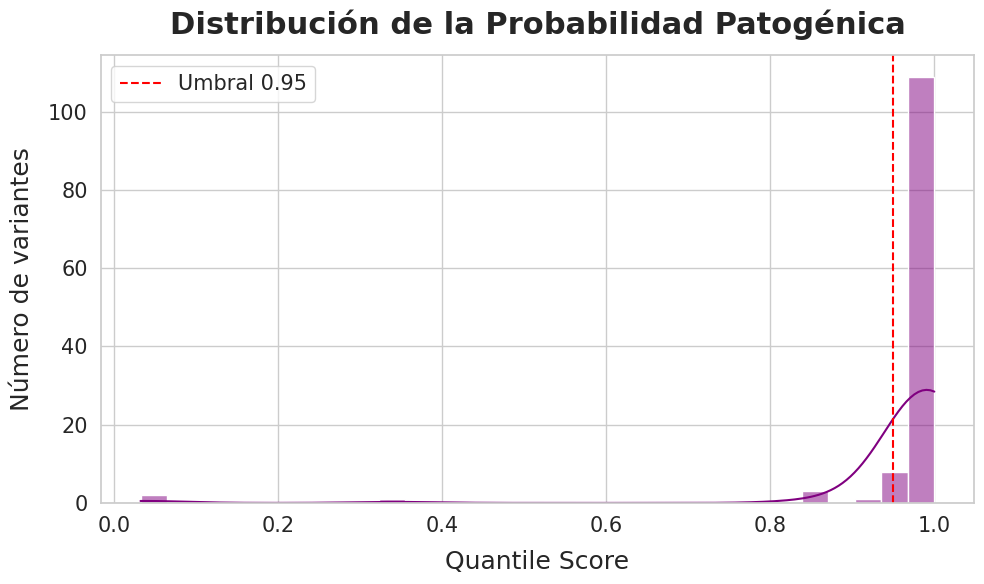

El 93.5% de las variantes están en el top 5% genómico.


In [29]:
plt.figure(figsize=(10, 6))
sns.histplot(df_maestra['quantile_score'], bins=30, kde=True, color='purple')
plt.axvline(0.95, color='red', linestyle='--', label='Umbral 0.95')

plt.title("Distribución de la Probabilidad Patogénica", fontsize=22, fontweight='bold', pad=15)

plt.xlabel("Quantile Score", fontsize=18, labelpad=10)
plt.ylabel("Número de variantes", fontsize=18, labelpad=10)

plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

plt.legend(fontsize=15)

plt.tight_layout()
plt.savefig('resultados/distribucion_quantile.pdf')
plt.show()

porcentaje_top = (df_maestra['quantile_score'] > 0.95).mean() * 100
print(f"El {porcentaje_top:.1f}% de las variantes están en el top 5% genómico.")

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


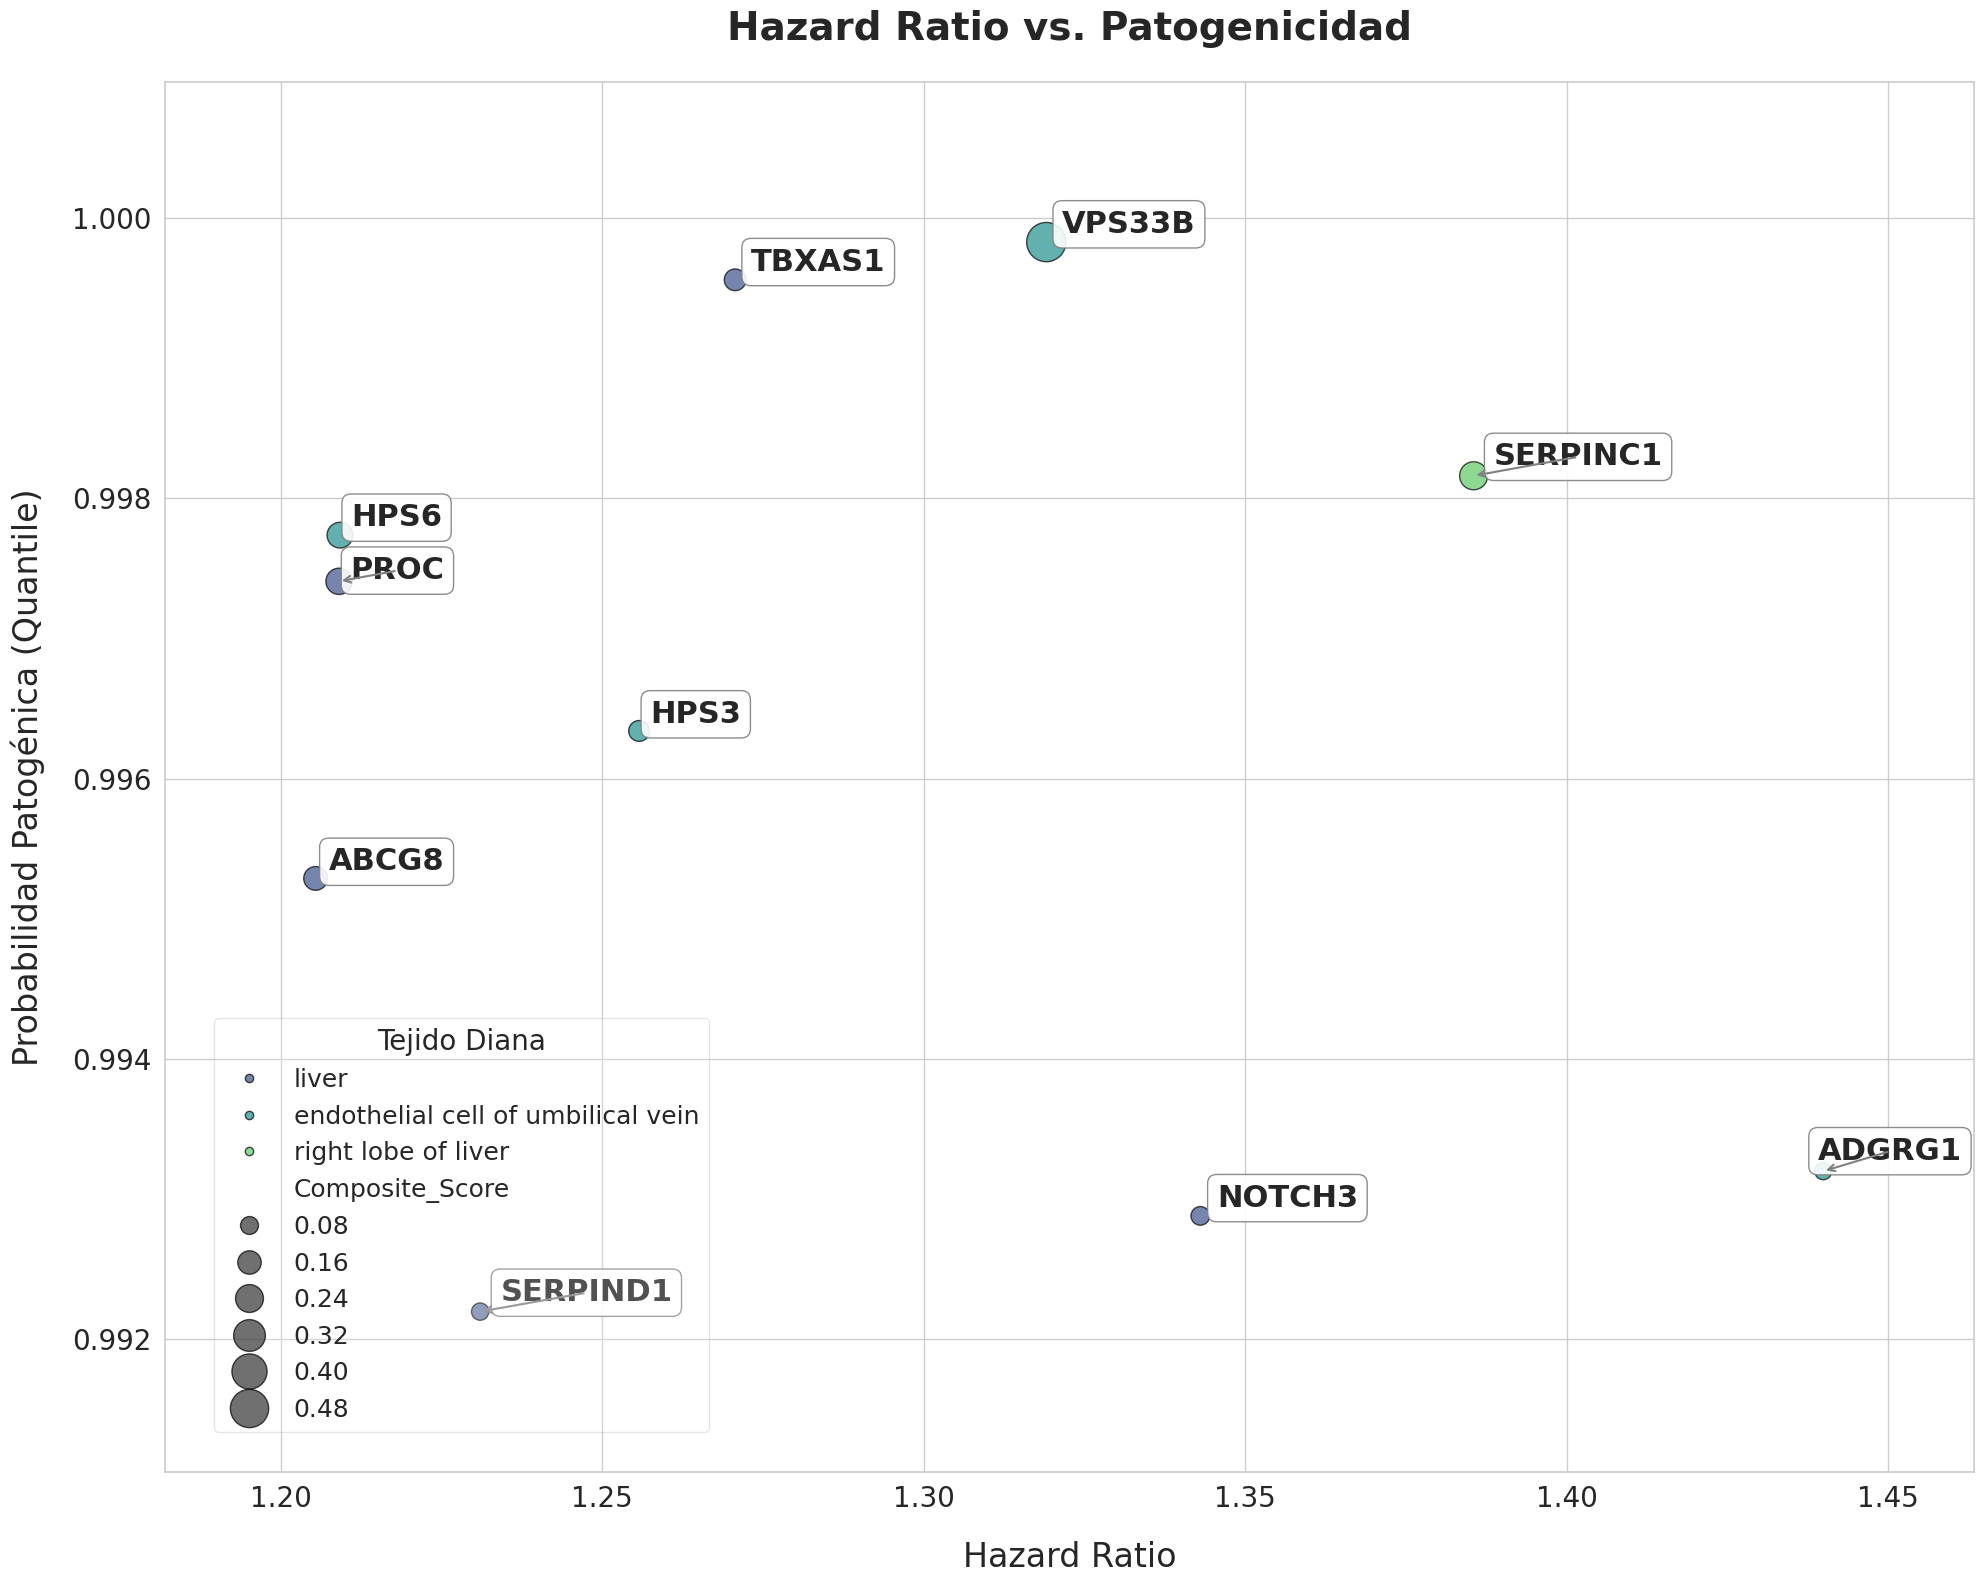

In [30]:
from adjustText import adjust_text

df_por_gen = df_maestra.groupby('Gen').agg({
    'Hazard_Ratio': 'mean',
    'quantile_score': 'max',
    'Composite_Score': 'max',
    'biosample_name': 'first'
}).reset_index()

top_genes_trombosis = df_por_gen[df_por_gen['Hazard_Ratio'] >= 1.20].copy()
genes_a_etiquetar = top_genes_trombosis.nlargest(15, 'Composite_Score')

plt.figure(figsize=(20, 16))
sns.set_theme(style="whitegrid")

scatter = sns.scatterplot(
    data=top_genes_trombosis, 
    x='Hazard_Ratio', y='quantile_score', 
    hue='biosample_name', size='Composite_Score', 
    sizes=(150, 800), 
    alpha=0.7, edgecolor='black', palette='viridis'
)

plt.margins(x=0.1, y=0.15) 

texts = []
for _, row in genes_a_etiquetar.iterrows():
    texts.append(plt.text(
        row.Hazard_Ratio, row.quantile_score, row.Gen, 
        fontsize=22,
        weight='bold', 
        bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.3')
    ))

adjust_text(
    texts, 
    arrowprops=dict(arrowstyle='->', color='gray', lw=1.5),
    force_points=(0.2, 0.5),
    force_text=(0.2, 0.5),
    expand_points=(1.5, 1.5),
    expand_text=(1.5, 1.5),
    max_iter=3000
)

plt.title("Hazard Ratio vs. Patogenicidad", fontsize=28, fontweight='bold', pad=30)
plt.xlabel("Hazard Ratio", fontsize=24, labelpad=20)
plt.ylabel("Probabilidad Patogénica (Quantile)", fontsize=24, labelpad=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

ax = plt.gca()
handles, labels = ax.get_legend_handles_labels()

plt.legend(
    handles=handles[1:],
    labels=labels[1:],
    title="Tejido Diana",
    fontsize=18,
    title_fontsize=20,
    loc='lower left',
    bbox_to_anchor=(0.02, 0.02),
    frameon=True,
    shadow=False,
    facecolor='white',
    edgecolor='gray',
    framealpha=0.2
)

plt.tight_layout()
plt.savefig('resultados/mapa_hr_patogenicidad_gen.pdf', format='pdf', dpi=300)
plt.show()

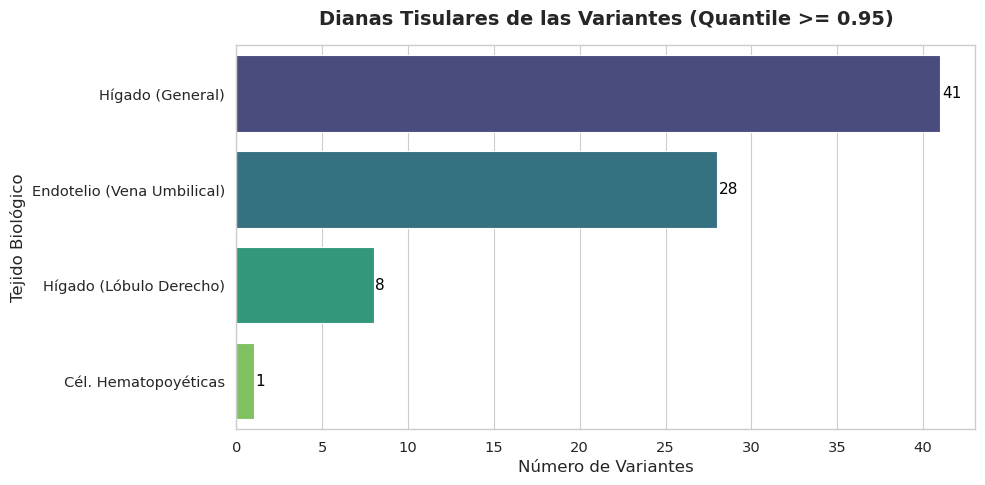

In [31]:
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
os.makedirs('resultados', exist_ok=True)

mapeo_tejidos = {
    'endothelial cell of umbilical vein': 'Endotelio (Vena Umbilical)',
    'right lobe of liver': 'Hígado (Lóbulo Derecho)',
    'left lobe of liver': 'Hígado (Lóbulo Izquierdo)',
    'posterior vena cava': 'Vena Cava Posterior',
    'hematopoietic multipotent progenitor cell': 'Cél. Hematopoyéticas',
    'liver': 'Hígado (General)'
}
df_maestra['Tejido_TFM'] = df_maestra['biosample_name'].replace(mapeo_tejidos)
df_tejidos = df_maestra[df_maestra['Tejido_TFM'] != 'Bajo Impacto / Otros'].copy()
df_top = df_tejidos[df_tejidos['quantile_score'] >= 0.99].copy()


plt.figure(figsize=(10, 5))
conteo_tejidos = df_top['Tejido_TFM'].value_counts().reset_index()
conteo_tejidos.columns = ['Tejido', 'Numero_Variantes']

sns.barplot(data=conteo_tejidos, y='Tejido', x='Numero_Variantes', palette='viridis')
plt.title("Dianas Tisulares de las Variantes (Quantile >= 0.95)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Número de Variantes", fontsize=12)
plt.ylabel("Tejido Biológico", fontsize=12)

for index, value in enumerate(conteo_tejidos['Numero_Variantes']):
    plt.text(value + 0.1, index, str(value), color='black', va="center", fontsize=11)

plt.tight_layout()
plt.savefig('resultados/tropismo_tisular.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [32]:
distribucion_total = df_tejidos['Tejido_TFM'].value_counts()
porcentaje_total = df_tejidos['Tejido_TFM'].value_counts(normalize=True) * 100

df_distribucion = pd.DataFrame({
    'Cantidad': distribucion_total,
    'Porcentaje': porcentaje_total.map('{:.1f}%'.format)
})

print(" DISTRIBUCIÓN GLOBAL DE VARIANTES POR TEJIDO")
print(df_distribucion)

 DISTRIBUCIÓN GLOBAL DE VARIANTES POR TEJIDO
                            Cantidad Porcentaje
Tejido_TFM                                     
Hígado (General)                  58      46.8%
Endotelio (Vena Umbilical)        53      42.7%
Hígado (Lóbulo Derecho)           12       9.7%
Cél. Hematopoyéticas               1       0.8%
